<!--Now we have done the following things -->
Dataset
   ↓
EDA ← WE ARE HERE
   ↓
Data Cleaning
   ↓
Preprocessing
   ↓
Feature Engineering
   ↓
Train/Test Split
   ↓
Model Training
   ↓
Evaluation
   ↓
Save .pkl
   ↓
FastAPI
   ↓
Docker

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")

All libraries imported successfully!


In [42]:
df = pd.read_csv("../data/loan_approval_dataset_1000_records.csv")

df.head()

,Loan_ID,Age,Gender,Married,Education,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Debt_to_Income,Property_Ownership,Dependents,Loan_Status
0,LN100001,59,Male,No,Not Graduate,Business,1537000.0,715.0,703000.0,60,2,0.31,Owned,2,Rejected
1,LN100002,49,Female,No,Graduate,Salaried,547000.0,693.0,143000.0,60,3,0.34,Rented,NaN,Rejected
2,LN100003,35,Female,Yes,Not Graduate,Salaried,543000.0,668.0,143000.0,48,2,0.28,Rented,3+,Rejected
3,LN100004,28,Male,Yes,Not Graduate,Salaried,327000.0,705.0,266000.0,60,2,0.37,Owned,2,Rejected
4,LN100005,41,Male,Yes,Graduate,Salaried,266000.0,652.0,197000.0,60,0,0.24,Owned,0,Approved


In [43]:
df.shape

(1000, 15)

In [44]:
df.columns

Index(['Loan_ID', 'Age', 'Gender', 'Married', 'Education', 'Employment_Type',
       'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term',
       'Existing_Loans', 'Debt_to_Income', 'Property_Ownership', 'Dependents',
       'Loan_Status'],
      dtype='str')

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             1000 non-null   str    
 1   Age                 1000 non-null   int64  
 2   Gender              980 non-null    str    
 3   Married             985 non-null    str    
 4   Education           980 non-null    str    
 5   Employment_Type     975 non-null    str    
 6   Annual_Income       985 non-null    float64
 7   Credit_Score        975 non-null    float64
 8   Loan_Amount         985 non-null    float64
 9   Loan_Term           1000 non-null   int64  
 10  Existing_Loans      1000 non-null   int64  
 11  Debt_to_Income      980 non-null    float64
 12  Property_Ownership  980 non-null    str    
 13  Dependents          980 non-null    str    
 14  Loan_Status         1000 non-null   str    
dtypes: float64(4), int64(3), str(8)
memory usage: 117.3 KB


In [46]:
df.describe()

,Age,Annual_Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Debt_to_Income
count,1000.000000,9.850000e+02,975.000000,9.850000e+02,1000.000000,1000.000000,980.000000
mean,40.991000,6.928954e+05,688.792821,3.333442e+05,42.480000,1.115000,0.249010
std,11.780055,3.988081e+05,66.052948,2.364907e+05,15.692541,1.107701,0.081212
min,21.000000,1.800000e+05,450.000000,5.000000e+04,12.000000,0.000000,0.050000
25%,31.000000,4.220000e+05,641.000000,1.760000e+05,36.000000,0.000000,0.190000
50%,42.000000,6.000000e+05,690.000000,2.780000e+05,36.000000,1.000000,0.240000
75%,51.250000,8.400000e+05,738.000000,4.330000e+05,60.000000,2.000000,0.300000
max,60.000000,3.000000e+06,850.000000,1.500000e+06,60.000000,4.000000,0.570000


In [47]:
df.isnull().sum()

Loan_ID                0
Age                    0
Gender                20
Married               15
Education             20
Employment_Type       25
Annual_Income         15
Credit_Score          25
Loan_Amount           15
Loan_Term              0
Existing_Loans         0
Debt_to_Income        20
Property_Ownership    20
Dependents            20
Loan_Status            0
dtype: int64

In [48]:
df["Loan_Status"].value_counts()

Loan_Status
Approved    509
Rejected    491
Name: count, dtype: int64

In [49]:
df["Loan_Status"].value_counts(normalize=True) * 100

Loan_Status
Approved    50.9
Rejected    49.1
Name: proportion, dtype: float64

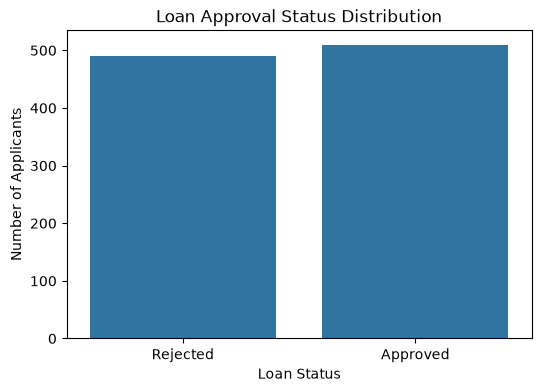

In [50]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

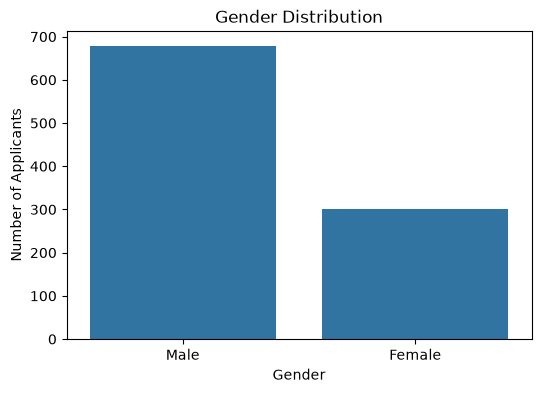

In [51]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")

plt.show()

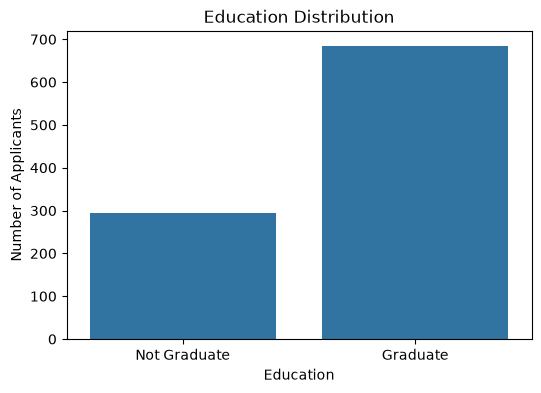

In [52]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Education")

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()

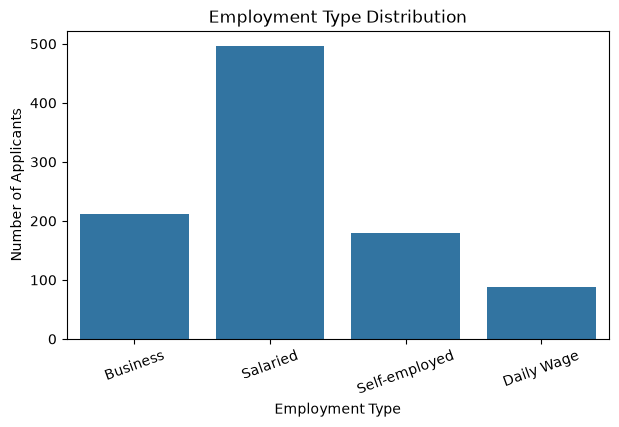

In [53]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="Employment_Type")

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.show()

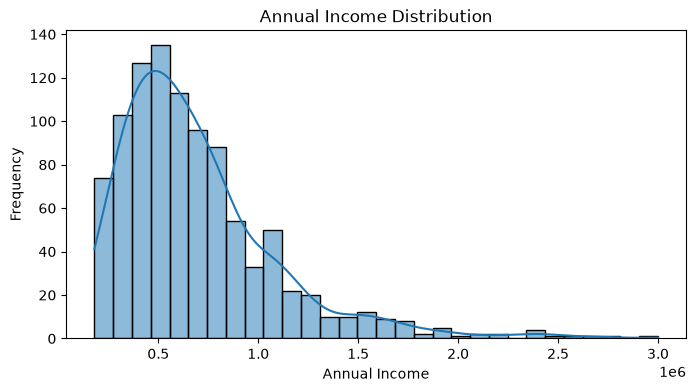

In [54]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Annual_Income", bins=30, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

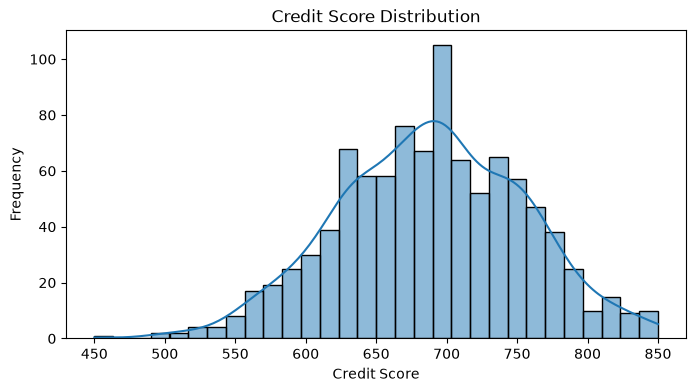

In [55]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Credit_Score", bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

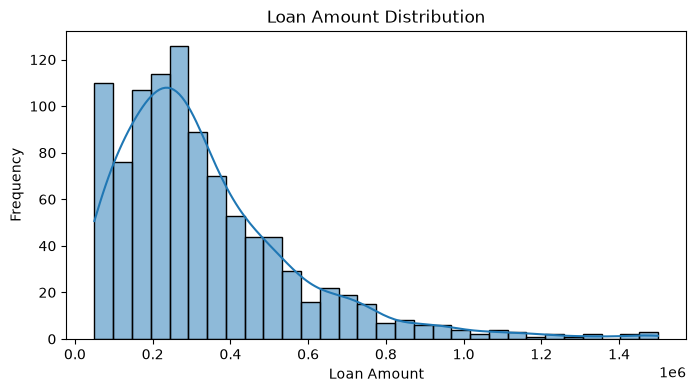

In [56]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Loan_Amount", bins=30, kde=True)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

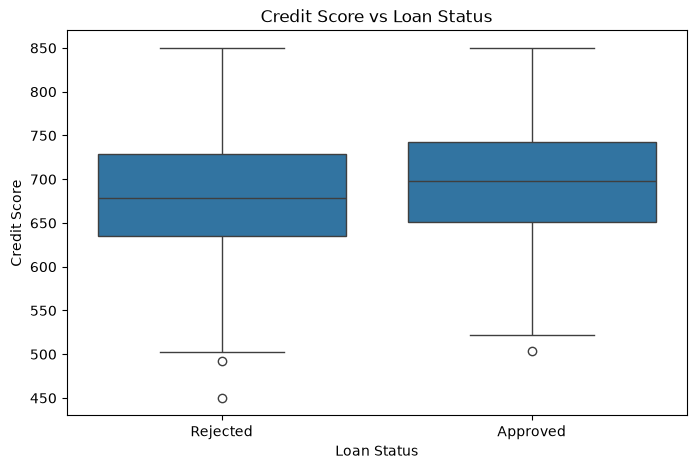

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Loan_Status", y="Credit_Score")

plt.title("Credit Score vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")

plt.show()

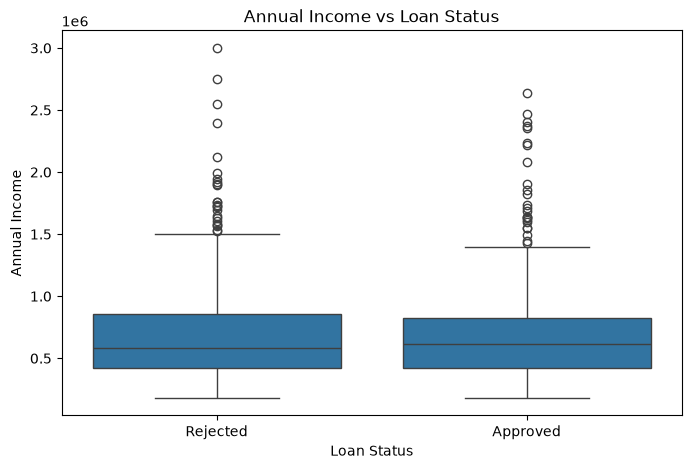

In [58]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Loan_Status", y="Annual_Income")

plt.title("Annual Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

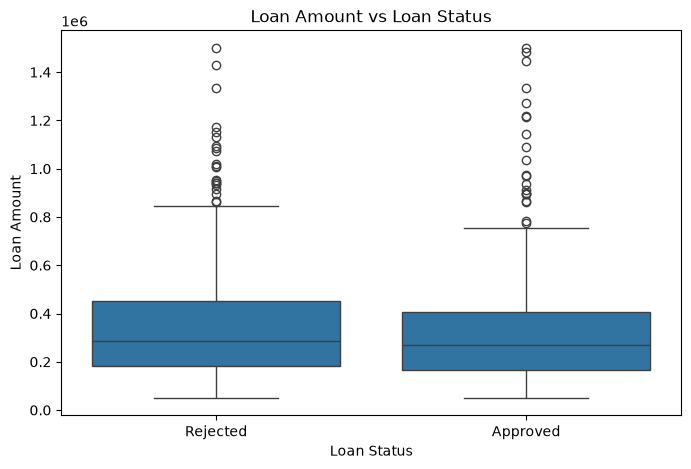

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Loan_Status", y="Loan_Amount")

plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

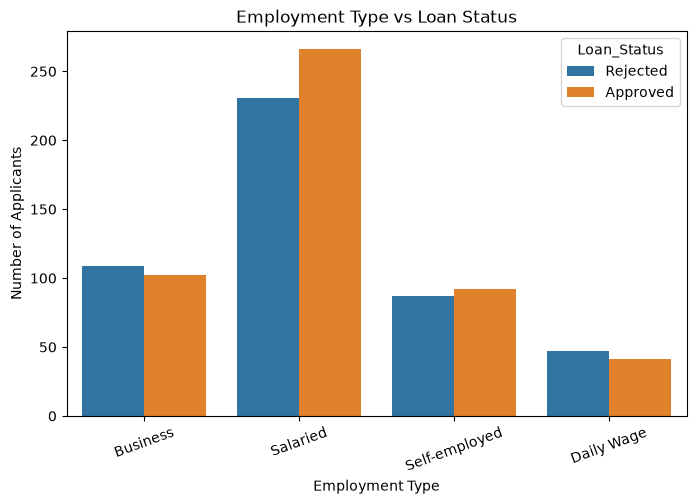

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Employment_Type", hue="Loan_Status")

plt.title("Employment Type vs Loan Status")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.show()

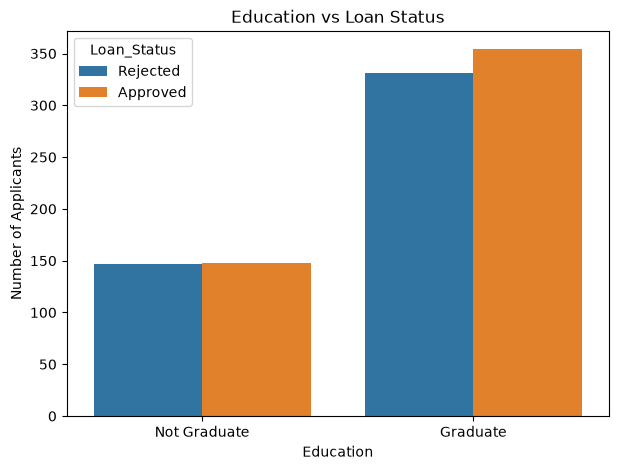

In [61]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Education", hue="Loan_Status")

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.show()

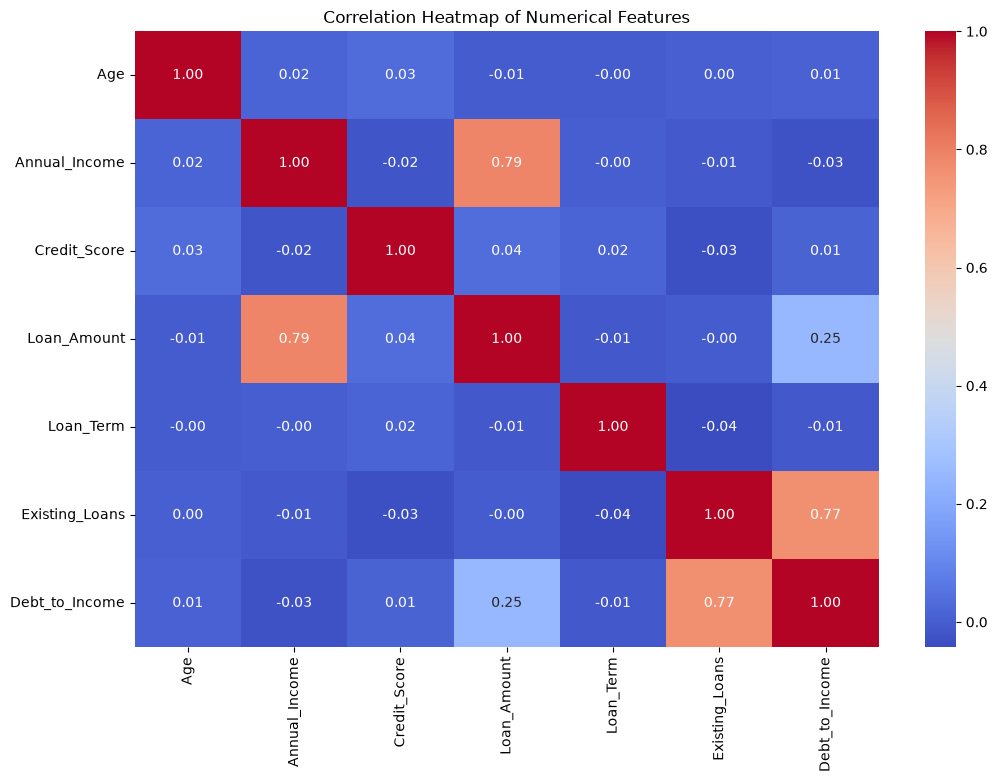

In [62]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

Data cleaning and preprocessing

In [63]:
df_clean = df.copy()

df_clean.head()

,Loan_ID,Age,Gender,Married,Education,Employment_Type,Annual_Income,Credit_Score,Loan_Amount,Loan_Term,Existing_Loans,Debt_to_Income,Property_Ownership,Dependents,Loan_Status
0,LN100001,59,Male,No,Not Graduate,Business,1537000.0,715.0,703000.0,60,2,0.31,Owned,2,Rejected
1,LN100002,49,Female,No,Graduate,Salaried,547000.0,693.0,143000.0,60,3,0.34,Rented,NaN,Rejected
2,LN100003,35,Female,Yes,Not Graduate,Salaried,543000.0,668.0,143000.0,48,2,0.28,Rented,3+,Rejected
3,LN100004,28,Male,Yes,Not Graduate,Salaried,327000.0,705.0,266000.0,60,2,0.37,Owned,2,Rejected
4,LN100005,41,Male,Yes,Graduate,Salaried,266000.0,652.0,197000.0,60,0,0.24,Owned,0,Approved


In [64]:
df_clean.isnull().sum()
# ===================Tells us which columns must need treatments====================

Loan_ID                0
Age                    0
Gender                20
Married               15
Education             20
Employment_Type       25
Annual_Income         15
Credit_Score          25
Loan_Amount           15
Loan_Term              0
Existing_Loans         0
Debt_to_Income        20
Property_Ownership    20
Dependents            20
Loan_Status            0
dtype: int64

In [65]:
df_clean.duplicated().sum()
# ========chdecking if duplictes exist============

np.int64(0)

In [66]:
df_clean = df_clean.drop_duplicates()
# ========If duplicates exist, remove them:============

In [67]:
df_clean.duplicated().sum()
# ============Verifying duplicates after removing===========

np.int64(0)

Feature Engineering

In [68]:
# our target is laon status and And Loan_ID is only an identifier, so we should not use it as a predictive feature.
X = df_clean.drop(columns=["Loan_Status", "Loan_ID"])
y = df_clean["Loan_Status"]

In [69]:
# X = Applicant information
# y = Loan_Status
X.head()
y.head()

0    Rejected
1    Rejected
2    Rejected
3    Rejected
4    Approved
Name: Loan_Status, dtype: str

In [70]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Loan_Term', 'Existing_Loans', 'Debt_to_Income']

Categorical Features:
['Gender', 'Married', 'Education', 'Employment_Type', 'Property_Ownership', 'Dependents']


C:\Users\admin\AppData\Local\Temp\ipykernel_7564\379314771.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


Train Test and Split

In [71]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [72]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 13)
Testing data: (200, 13)


Build the preprocessing pipeline

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [74]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [75]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Why we are doing this actually
Our complete ML pipeline will eventually be:
Raw Data
   ↓
Train/Test Split
   ↓
Preprocessing
   ├── Numerical → Median Imputation
   │
   └── Categorical
          ↓
       Most Frequent
          ↓
       One-Hot Encoding
   ↓
Machine Learning Model
   ↓
Prediction
This is better than manually cleaning the dataset because the same preprocessing steps will automatically be applied when our FastAPI application receives a new loan application.

Building a model now

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

Training the model

In [78]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Approved','Rejected']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Gender','Married',...,'Debt_to_Income','Property_Ownership', 'Dependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [79]:
# ===============Making predictions================
y_pred = logistic_model.predict(X_test)
print(y_pred[:20])

['Rejected' 'Approved' 'Approved' 'Rejected' 'Rejected' 'Approved'
 'Approved' 'Approved' 'Approved' 'Rejected' 'Approved' 'Approved'
 'Rejected' 'Approved' 'Rejected' 'Rejected' 'Approved' 'Approved'
 'Rejected' 'Approved']


Evaluating the model

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Approved"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Approved"))
print("F1 Score :", f1_score(y_test, y_pred, pos_label="Approved"))

Accuracy : 0.595
Precision: 0.5882352941176471
Recall   : 0.6862745098039216
F1 Score : 0.6334841628959276


In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Approved       0.59      0.69      0.63       102
    Rejected       0.60      0.50      0.55        98

    accuracy                           0.59       200
   macro avg       0.60      0.59      0.59       200
weighted avg       0.60      0.59      0.59       200



In [82]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[70 32]
 [49 49]]


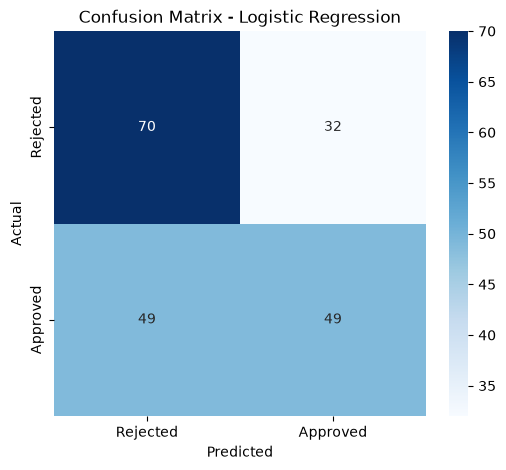

In [83]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [84]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = logistic_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(
    (y_test == "Approved").astype(int),
    y_prob
)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.40756302521008403


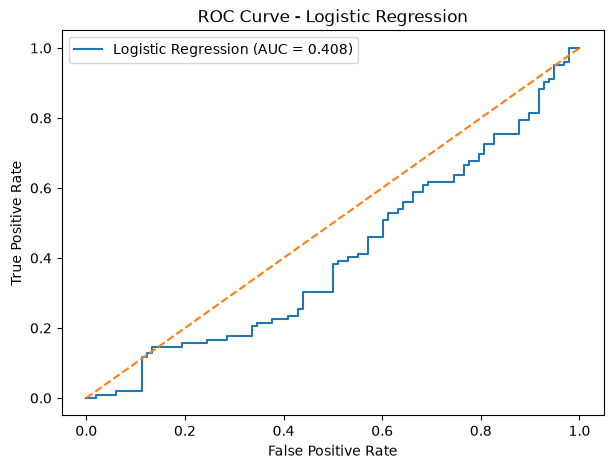

In [85]:
fpr, tpr, thresholds = roc_curve(
    (y_test == "Approved").astype(int),
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier

In [87]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Credit_Score",
    "Loan_Amount",
    "Loan_Term",
    "Existing_Loans",
    "Debt_to_Income"
]

categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Employment_Type",
    "Property_Ownership",
    "Dependents"
]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [88]:
# Random forest pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [92]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Approved','Rejected']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Gender','Married',...,'Debt_to_Income','Property_Ownership', 'Dependents']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [93]:
rf_pred = random_forest_model.predict(X_test)

In [94]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, pos_label="Approved"))
print("Recall   :", recall_score(y_test, rf_pred, pos_label="Approved"))
print("F1 Score :", f1_score(y_test, rf_pred, pos_label="Approved"))

Accuracy : 0.575
Precision: 0.5739130434782609
Recall   : 0.6470588235294118
F1 Score : 0.6082949308755761


In [95]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

    Approved       0.57      0.65      0.61       102
    Rejected       0.58      0.50      0.54        98

    accuracy                           0.57       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.58      0.57      0.57       200



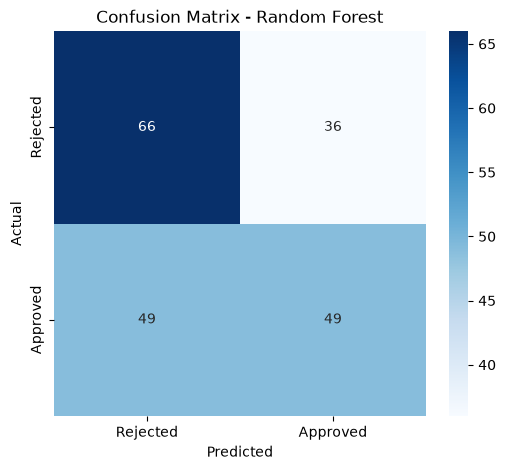

In [96]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Comparing Both Logistic and Random forest 

In [97]:
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_precision = precision_score(y_test, y_pred, pos_label="Approved")
logistic_recall = recall_score(y_test, y_pred, pos_label="Approved")
logistic_f1 = f1_score(y_test, y_pred, pos_label="Approved")

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, pos_label="Approved")
rf_recall = recall_score(y_test, rf_pred, pos_label="Approved")
rf_f1 = f1_score(y_test, rf_pred, pos_label="Approved")

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1 Score": [logistic_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.595,0.588235,0.686275,0.633484
1,Random Forest,0.575,0.573913,0.647059,0.608295


In [98]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

c:\AI\Python\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross-validation scores: [0.5875  0.56875 0.625   0.63125 0.66875]
Mean CV Accuracy: 0.61625
Standard Deviation: 0.03504461442219045


In [99]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Random Forest CV scores:", rf_cv_scores)
print("Mean CV Accuracy:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

Random Forest CV scores: [0.58125 0.63125 0.59375 0.575   0.60625]
Mean CV Accuracy: 0.5974999999999999
Standard Deviation: 0.01999999999999999


Hyper Tuning 

In [100]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

The down code may take a little time because we're testing multiple combinations.

In [101]:
grid_search = GridSearchCV(
    random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [102]:
# Choosing the best feature 
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [103]:
print("Best Cross-Validation Accuracy:")
print(grid_search.best_score_)

Best Cross-Validation Accuracy:
0.60875


In [105]:
# Get the best complete pipeline
best_model = grid_search.best_estimator_

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Annual_Income',
                                                   'Credit_Score',
                                                   'Loan_Amount', 'Loan_Term',
                                                   'Existing_Loans',
                                                   'Debt_to_Income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Married',
                                                   'Education',
                                                   'Employment_Type',
                                                   'Property_Ownership',
                                                   'Dependents'])])),
                ('model',
         

In [106]:
final_pred = best_model.predict(X_test)

In [107]:
# Final Evaluation 
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred, pos_label="Approved"))
print("Recall   :", recall_score(y_test, final_pred, pos_label="Approved"))
print("F1 Score :", f1_score(y_test, final_pred, pos_label="Approved"))

Accuracy : 0.605
Precision: 0.5950413223140496
Recall   : 0.7058823529411765
F1 Score : 0.6457399103139013


In [108]:
# Final Report
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

    Approved       0.60      0.71      0.65       102
    Rejected       0.62      0.50      0.55        98

    accuracy                           0.60       200
   macro avg       0.61      0.60      0.60       200
weighted avg       0.61      0.60      0.60       200



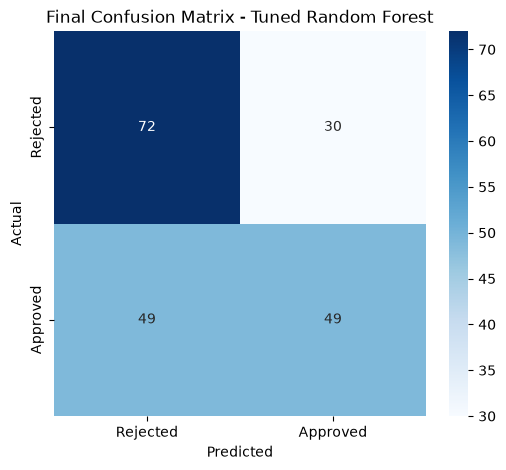

In [109]:
# Final Confusion Matrix
final_cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Final Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [110]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negative (TN):", tn)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Positive (TP):", tp)

True Negative (TN): 72
False Positive (FP): 30
False Negative (FN): 49
True Positive (TP): 49


Finally Saving the model 

In [112]:
import joblib
joblib.dump(
    best_model,
    "../models/loan_approval_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!
